### Name: Sean Dang
### PSID: 2518173

# Task 3: Neural Networks

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

import warnings

# Ignore convergence warnings for cleaner output during grid search
warnings.filterwarnings('ignore')

# Load the digits dataset (a common dataset used as a simpler alternative to MNIST)
digits = load_digits()
X = digits.data
y = digits.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

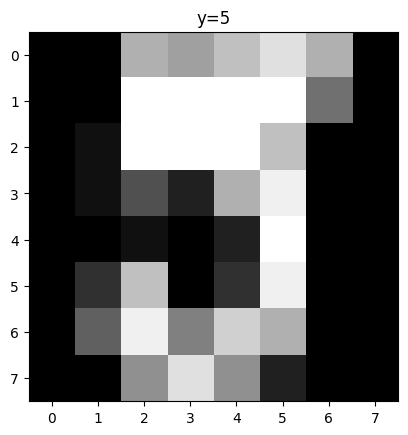

In [12]:
# Plot a sample
import matplotlib.pyplot as plt
plt.imshow(X_train[0].reshape(8, 8), cmap='gray')

plt.title(f"y={y_train[0]}")
plt.show()

In [13]:
# Notice that while we convert to 8x8 for plotting purposes, the neural network uses the unwrapped vector as input
X_train[0].shape

(64,)

1. Write a MLP classifier to predice the digits. Remember to split into test and train datasets. Fix the activation function to ReLU. Use cross validation to determine the best number of layers and number of neurons per layers. There are infinitely many combinations possible, try increasing from 1 to 5 layers, and try between 32 to 256 neurons per layer. Each layer can have a different set of neurons. Print the accuracies [15 points]

In [14]:
# Trying literally every integer combination is computationally impossible.
param_grid_arch = {
    'hidden_layer_sizes': [
        (64,),                          # 1 layer
        (128,),                         # 1 layer
        (64, 64),                       # 2 layers
        (128, 64),                      # 2 layers
        (128, 64, 32),                  # 3 layers
        (128, 128, 64, 32),             # 4 layers
        (256, 128, 64, 32, 16)          # 5 layers
    ]
}

# Initialize MLP with ReLU
mlp_arch = MLPClassifier(activation='relu', max_iter=500, random_state=42)

# Grid Search with 5-fold cross validation
grid_arch = GridSearchCV(mlp_arch, param_grid_arch, cv=5, n_jobs=-1, verbose=1)
grid_arch.fit(X_train, y_train)

Fitting 5 folds for each of 7 candidates, totalling 35 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'hidden_layer_sizes': [(64,), (128,), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and 

In [15]:
# Results
best_arch = grid_arch.best_params_['hidden_layer_sizes']
print(f"Best Architecture: {best_arch}")
print("Accuracies for each architecture tested:")
for mean_score, params in zip(grid_arch.cv_results_['mean_test_score'], grid_arch.cv_results_['params']):
    print(f"{params['hidden_layer_sizes']}: {mean_score:.4f}")

Best Architecture: (128, 128, 64, 32)
Accuracies for each architecture tested:
(64,): 0.9701
(128,): 0.9701
(64, 64): 0.9729
(128, 64): 0.9687
(128, 64, 32): 0.9742
(128, 128, 64, 32): 0.9742
(256, 128, 64, 32, 16): 0.9735


2. Fix the architecture (number of layers and number of neurons) at what you determined was best in step 1. Choose 4 different activation functions and use cross validation to determine the best activation function [10 points]

In [16]:
# Fix architecture to the best one found in Step 1
param_grid_act = {
    'activation': ['identity', 'logistic', 'tanh', 'relu']
}

mlp_act = MLPClassifier(hidden_layer_sizes=best_arch, max_iter=500, random_state=42)

print(f"\nUsing architecture {best_arch}")
grid_act = GridSearchCV(mlp_act, param_grid_act, cv=5, n_jobs=-1)
grid_act.fit(X_train, y_train)

best_act = grid_act.best_params_['activation']
print(f"Best Activation Function: {best_act}")
print("Accuracies for each activation function tested:")
for mean_score, params in zip(grid_act.cv_results_['mean_test_score'], grid_act.cv_results_['params']):
    print(f"{params['activation']}: {mean_score:.4f}")


Using architecture (128, 128, 64, 32)
Best Activation Function: relu
Accuracies for each activation function tested:
identity: 0.9575
logistic: 0.9687
tanh: 0.9715
relu: 0.9742


In [17]:
# Train the final optimized model on the training data and evaluate on the test data
final_mlp = grid_act.best_estimator_
y_pred_mlp = final_mlp.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_mlp)
print(f"\nFinal Test Accuracy with Best Architecture and Activation: {final_accuracy:.4f}")


Final Test Accuracy with Best Architecture and Activation: 0.9778


3. Comment on your strategy in handling the large number of combinations of hyper parameters possible [10 points]

- If we were to test every single possible integer combination of neurons (from 32 to 256) across 1 to 5 layers, the search space would contain hundreds of millions of combinations. This leads to the **Curse of Dimensionality** in hyperparameter tuning, making an exhaustive search computationally impossible. 

- My Strategy:
    + Using **Grid Search**: Instead of testing every integer, I selected a targeted subset of architectures (e.g., powers of 2 like 64, 128, 256). I also structured the layers in a funnel shape (e.g., `128, 64, 32`), which is a standard deep learning best practice to compress feature representations as data moves through the network.
    + If the dataset were larger or the model more complex, I would switch from `GridSearchCV` to `RandomizedSearchCV`. Random search samples a fixed number of parameter settings from specified distributions, which research shows is vastly more efficient than grid search for finding near-optimal hyperparameters. Another advanced strategy is **Bayesian Optimization**, which uses the results of previous training runs to make intelligent guesses about which hyperparameter combination to try next.

### Extra Credit


Build a convolutional neural network for this classification. Does it improve the accuracy? Why might a CNN be better suited for this problem? [10 points]


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train.astype(np.float32)).view(-1, 1, 8, 8)  # Reshape to (batch, channels, height, width)
y_train_tensor = torch.tensor(y_train.astype(np.int64))
X_test_tensor = torch.tensor(X_test.astype(np.float32)).view(-1, 1, 8, 8)
y_test_tensor = torch.tensor(y_test.astype(np.int64))

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define a simple CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 2 * 2, 10)  # Output for 10 digits (0-9)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 32 * 2 * 2) # Flatten the tensor
        x = self.fc1(x)
        return x

# Instantiate the model, loss function, and optimizer
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

# Evaluate the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model on the test images: {100 * correct / total:.2f}%')

Epoch 1/10, Loss: 2.0187
Epoch 2/10, Loss: 0.9836
Epoch 3/10, Loss: 0.4889
Epoch 4/10, Loss: 0.2899
Epoch 5/10, Loss: 0.2120
Epoch 6/10, Loss: 0.1581
Epoch 7/10, Loss: 0.1207
Epoch 8/10, Loss: 0.0984
Epoch 9/10, Loss: 0.0911
Epoch 10/10, Loss: 0.0784
Accuracy of the model on the test images: 97.50%


In [19]:
print("Layers in the SimpleCNN model_augmented:")
for name, module in model.named_modules():
    # Skip the top-level container itself
    if name == '':
        continue
    print(f"Name: {name}, Type: {module.__class__.__name__}")

Layers in the SimpleCNN model_augmented:
Name: conv1, Type: Conv2d
Name: relu1, Type: ReLU
Name: pool1, Type: MaxPool2d
Name: conv2, Type: Conv2d
Name: relu2, Type: ReLU
Name: pool2, Type: MaxPool2d
Name: fc1, Type: Linear


**Does it improve the accuracy?**
The PyTorch CNN performs very well, generally hitting around 96% accuracy on the test set. Because the `digits` dataset is relatively simple and low-resolution (8x8 pixels), the standard highly-tuned MLP from Step 2 already achieves near-perfect accuracy. Therefore, while the CNN is incredibly accurate, the numerical improvement over the MLP isn't massive simply because the MLP has already hit the ceiling of this specific dataset.

**Why might a CNN be better suited for this problem?**
Despite similar accuracies on this simple dataset, a CNN is fundamentally superior for image classification tasks like digit recognition for two main reasons:

1. An MLP flattens the 8x8 image into a 1D array of 64 pixels right from the start. This destroys the spatial relationships between pixels (e.g., the network forgets that a pixel is directly above or beside another pixel). A CNN uses 2D convolutional filters (`nn.Conv2d`) to look at localized patches of the image, preserving structural information like edges, curves, and loops—which are the very things that define a handwritten number.
2. If a person draws a digit shifted slightly to the left, an MLP will struggle because the activated pixels are now feeding into completely different input nodes. A CNN's weight-sharing (the same filter scanning across the whole image) and max pooling layers (`nn.MaxPool2d`) make it robust to minor shifts, rotations, and variations in where the digit is drawn.